In [2]:
from datasets import load_dataset

/Users/yasir/Desktop/workspace/insurance_ai_engine/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
dataset = load_dataset(path =  "amaye15/invoices-google-ocr", split=None, cache_dir= "../data")

In [7]:
dataset

DatasetDict({
    train: Dataset({
        features: ['pixel_values', 'label', 'ocr'],
        num_rows: 13463
    })
    test: Dataset({
        features: ['pixel_values', 'label', 'ocr'],
        num_rows: 3366
    })
})

In [3]:
print("Dataset splits:", list(dataset.keys()))
print("\nTrain split info:")
print(f"Number of examples: {len(dataset['train'])}")
print(f"Features: {dataset['train'].features}")
print(f"\nTest split info:")
print(f"Number of examples: {len(dataset['test'])}")
print(f"Features: {dataset['test'].features}")

Dataset splits: ['train', 'test']

Train split info:
Number of examples: 13463
Features: {'pixel_values': Image(mode=None, decode=True), 'label': ClassLabel(names=['Barcode', 'Invoice', 'Object', 'Receipt', 'Non-Object']), 'ocr': List({'bounding box': {'vertex 0': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 1': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 2': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 3': {'x': Value('int64'), 'y': Value('int64')}}, 'text': Value('string')})}

Test split info:
Number of examples: 3366
Features: {'pixel_values': Image(mode=None, decode=True), 'label': ClassLabel(names=['Barcode', 'Invoice', 'Object', 'Receipt', 'Non-Object']), 'ocr': List({'bounding box': {'vertex 0': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 1': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 2': {'x': Value('int64'), 'y': Value('int64')}, 'vertex 3': {'x': Value('int64'), 'y': Value('int64')}}, 'text': Value('string')})}


In [4]:
example = dataset['train'][0]
print("Example keys:", list(example.keys()))
print("\nExample content:")
for key, value in example.items():
    print(f"{key}: {str(value)[:100]}..." if len(str(value)) > 100 else f"{key}: {value}")

Example keys: ['pixel_values', 'label', 'ocr']

Example content:
pixel_values: <PIL.PngImagePlugin.PngImageFile image mode=RGB size=595x841 at 0x139B6CE90>
label: 1
ocr: [{'bounding box': {'vertex 0': {'x': 12, 'y': 27}, 'vertex 1': {'x': 566, 'y': 27}, 'vertex 2': {'x'...


In [5]:
label_names = dataset['train'].features['label'].names
all_labels = list(dataset['train']['label'])

samples = {}
for i, name in enumerate(label_names):
    if i in all_labels:
        samples[name] = all_labels.index(i)

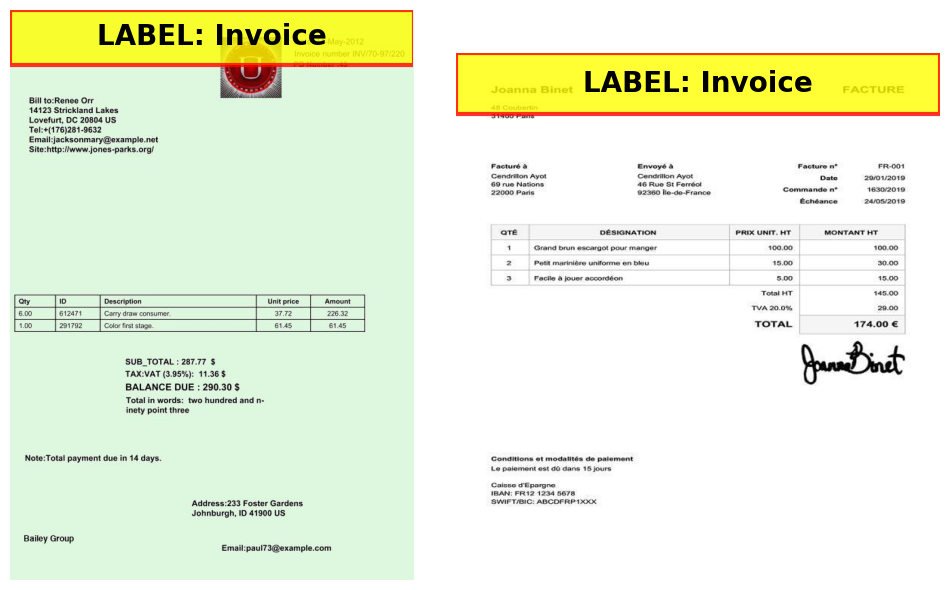

In [35]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import random

label_names = dataset['train'].features['label'].names
all_labels = list(dataset['train']['label'])

samples = []
for i, name in enumerate(label_names):
    indices = [idx for idx, lbl in enumerate(all_labels) if lbl == i]
    if indices:
        num_samples = random.randint(2, 3)
        samples.extend([(name, idx) for idx in random.sample(indices, min(num_samples, len(indices)))])

# Shuffle for random order
random.shuffle(samples)

fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 6))
if len(samples) == 1:
    axes = [axes]

for idx, (label, sample_idx) in enumerate(samples):
    img = dataset['train'][sample_idx]['pixel_values']
    axes[idx].imshow(img)
    w, h = img.size
    rect = Rectangle((0, 0), w, 80, linewidth=3, edgecolor='red', 
                     facecolor='yellow', alpha=0.8, zorder=10)
    axes[idx].add_patch(rect)
    axes[idx].text(w/2, 40, f'LABEL: {label}', ha='center', va='center',
                   fontsize=20, fontweight='bold', color='black', zorder=11)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


In [14]:
type(img)

PIL.PngImagePlugin.PngImageFile

## Eval


In [1]:


import sys
import os
import warnings
from datasets import load_dataset
from PIL import Image
import evaluate
from tqdm import tqdm

warnings.filterwarnings("ignore", category=UserWarning, module="tqdm")

sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd())))

from src.utils import encode_image, extract_ground_truth_text, clean_html_markdown, clean_ocr_text
from src.inference import infer_batch
from src.config import load_config

DATASET_NAME = "amaye15/invoices-google-ocr"
DATASET_SPLIT = "test"
NUM_SAMPLES = 500
BATCH_SIZE = 10
MAX_WORKERS = 5

config = load_config()
model_config = config.ocr_models[0]

dataset = load_dataset(path=DATASET_NAME, split=DATASET_SPLIT, cache_dir="../data")
sample = dataset.select(range(NUM_SAMPLES))
# sample = dataset

def extract_ground_truth(example):
    example["text"] = extract_ground_truth_text(example.get("ocr", []))
    return example

sample = sample.map(extract_ground_truth)

def prepare_image(img):
#     if isinstance(img, Image.Image):
#         img_rgb = img.convert("RGB")
#     else:
#         img_rgb = Image.fromarray(img).convert("RGB")
    return encode_image(img)

encoded_images = []
for example in tqdm(sample, desc="Encoding images", unit="image"):
    try:
        encoded_img = prepare_image(example["pixel_values"])
        encoded_images.append(encoded_img)
    except Exception:
        encoded_images.append(None)

batches = [
    (start_idx, encoded_images[start_idx:start_idx + BATCH_SIZE])
    for start_idx in range(0, len(encoded_images), BATCH_SIZE)
]

/Users/yasir/Desktop/workspace/insurance_ai_engine/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Encoding images: 100%|██████████| 500/500 [00:06<00:00, 71.96image/s]


In [3]:
# Overriding the prompt for the model for eval purposes, as it is a vision model capable of extracting layout 
model_config.prompt = "Extract the text from the above document as if you were reading it naturally without any additional formatting or markdown. or html tags"
model_config

ModelEval(name='nanonets/Nanonets-OCR2-3B', url=None, batch_size=10, prompt='Extract the text from the above document as if you were reading it naturally without any additional formatting or markdown. or html tags', max_workers=3, num_samples=100, active=True, save_results=True, results_dir='results', extra=None)

In [4]:
predictions = [""] * len(sample)

for start_idx, batch_images in tqdm(batches, desc="Processing batches", unit="batch"):
    valid_images = [img for img in batch_images if img is not None]
    
    if not valid_images:
        continue
    
    batch_results = infer_batch(valid_images, model_config, max_workers=MAX_WORKERS)
    
    result_idx = 0
    for i, img in enumerate(batch_images):
        if img is not None:
            predictions[start_idx + i] = batch_results[result_idx]
            result_idx += 1

Processing batches: 100%|██████████| 50/50 [39:35<00:00, 47.51s/batch]


In [5]:
predictions[0], cleaned_predictions[0], sample["text"][0]

NameError: name 'cleaned_predictions' is not defined

In [9]:
cleaned_predictions = [
    clean_ocr_text(pred) if pred else ""
    for pred in predictions
]

cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")
exact_match_metric = evaluate.load("exact_match")
chrf_metric = evaluate.load("chrf")
bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")

metrics_raw = {
    "cer": cer_metric.compute(predictions=predictions, references=sample["text"]),
    "wer": wer_metric.compute(predictions=predictions, references=sample["text"]),
    "exact_match": exact_match_metric.compute(predictions=predictions, references=sample["text"]),
    "chrf": chrf_metric.compute(predictions=predictions, references=sample["text"]),
    "bleu": bleu_metric.compute(predictions=predictions, references=[[ref] for ref in sample["text"]]),
    "rouge": rouge_metric.compute(predictions=predictions, references=sample["text"]),
    "meteor": meteor_metric.compute(predictions=predictions, references=sample["text"]),
}

metrics_cleaned = {
    "cer": cer_metric.compute(predictions=cleaned_predictions, references=sample["text"]),
    "wer": wer_metric.compute(predictions=cleaned_predictions, references=sample["text"]),
    "exact_match": exact_match_metric.compute(predictions=cleaned_predictions, references=sample["text"]),
    "chrf": chrf_metric.compute(predictions=cleaned_predictions, references=sample["text"]),
    "bleu": bleu_metric.compute(predictions=cleaned_predictions, references=[[ref] for ref in sample["text"]]),
    "rouge": rouge_metric.compute(predictions=cleaned_predictions, references=sample["text"]),
    "meteor": meteor_metric.compute(predictions=cleaned_predictions, references=sample["text"]),
}

results = {
    "model_config": {
        "name": model_config.name,
        "url": model_config.get_url(),
        "prompt": model_config.prompt,
        "batch_size": model_config.batch_size,
        "max_workers": model_config.max_workers,
    },
    "dataset_info": {
        "dataset_name": DATASET_NAME,
        "split": DATASET_SPLIT,
        "num_samples": len(sample),
    },
    "predictions": {
        "raw": predictions[:5],
        "cleaned": cleaned_predictions[:5],
    },
    "ground_truth": sample["text"][:5],
    "metrics": {
        "raw": metrics_raw,
        "cleaned": metrics_cleaned,
    },
    "processing_config": {
        "batch_size": BATCH_SIZE,
        "max_workers": MAX_WORKERS,
    },
}

results

[nltk_data] Downloading package wordnet to /Users/yasir/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/yasir/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/yasir/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


{'model_config': {'name': 'nanonets/Nanonets-OCR2-3B',
  'url': 'https://fpqr9yfck4x72w-8002.proxy.runpod.net/v1',
  'prompt': 'Extract the text from the above document as if you were reading it naturally without any additional formatting or markdown. or html tags',
  'batch_size': 10,
  'max_workers': 3},
 'dataset_info': {'dataset_name': 'amaye15/invoices-google-ocr',
  'split': 'test',
  'num_samples': 500},
 'predictions': {'raw': ["Date: 28-May-1994\nINVOICE ID INV68423104\n\nMiller Inc\nAddress:5190 Perry Passage\nKellyburgh, RI 60615 US\n\nBill to:Colton Sweeney\n3420 Woodard Neck Apt. 350\nBairdville, OK 08121 US\nTel:+(754)677-6649\nEmail:colemanglenda@example.net\nSite:https://carlson.com/\n\nEmail:marymoore@example.org\n\nThank you for choosing us!\n\nSUB_TOTAL : 239.63 EUR\n\nTOTAL : 249.11 EUR\n\n<table><tr><th>ITEMS</th><th>QUANTITY</th><th>PRICE</th><th>TAX</th><th>AMOUNT</th></tr><tr><td colspan='5'></td></tr><tr><td>Model.</td><td>1.00</td><td>$97.70</td><td>$0.00</td>

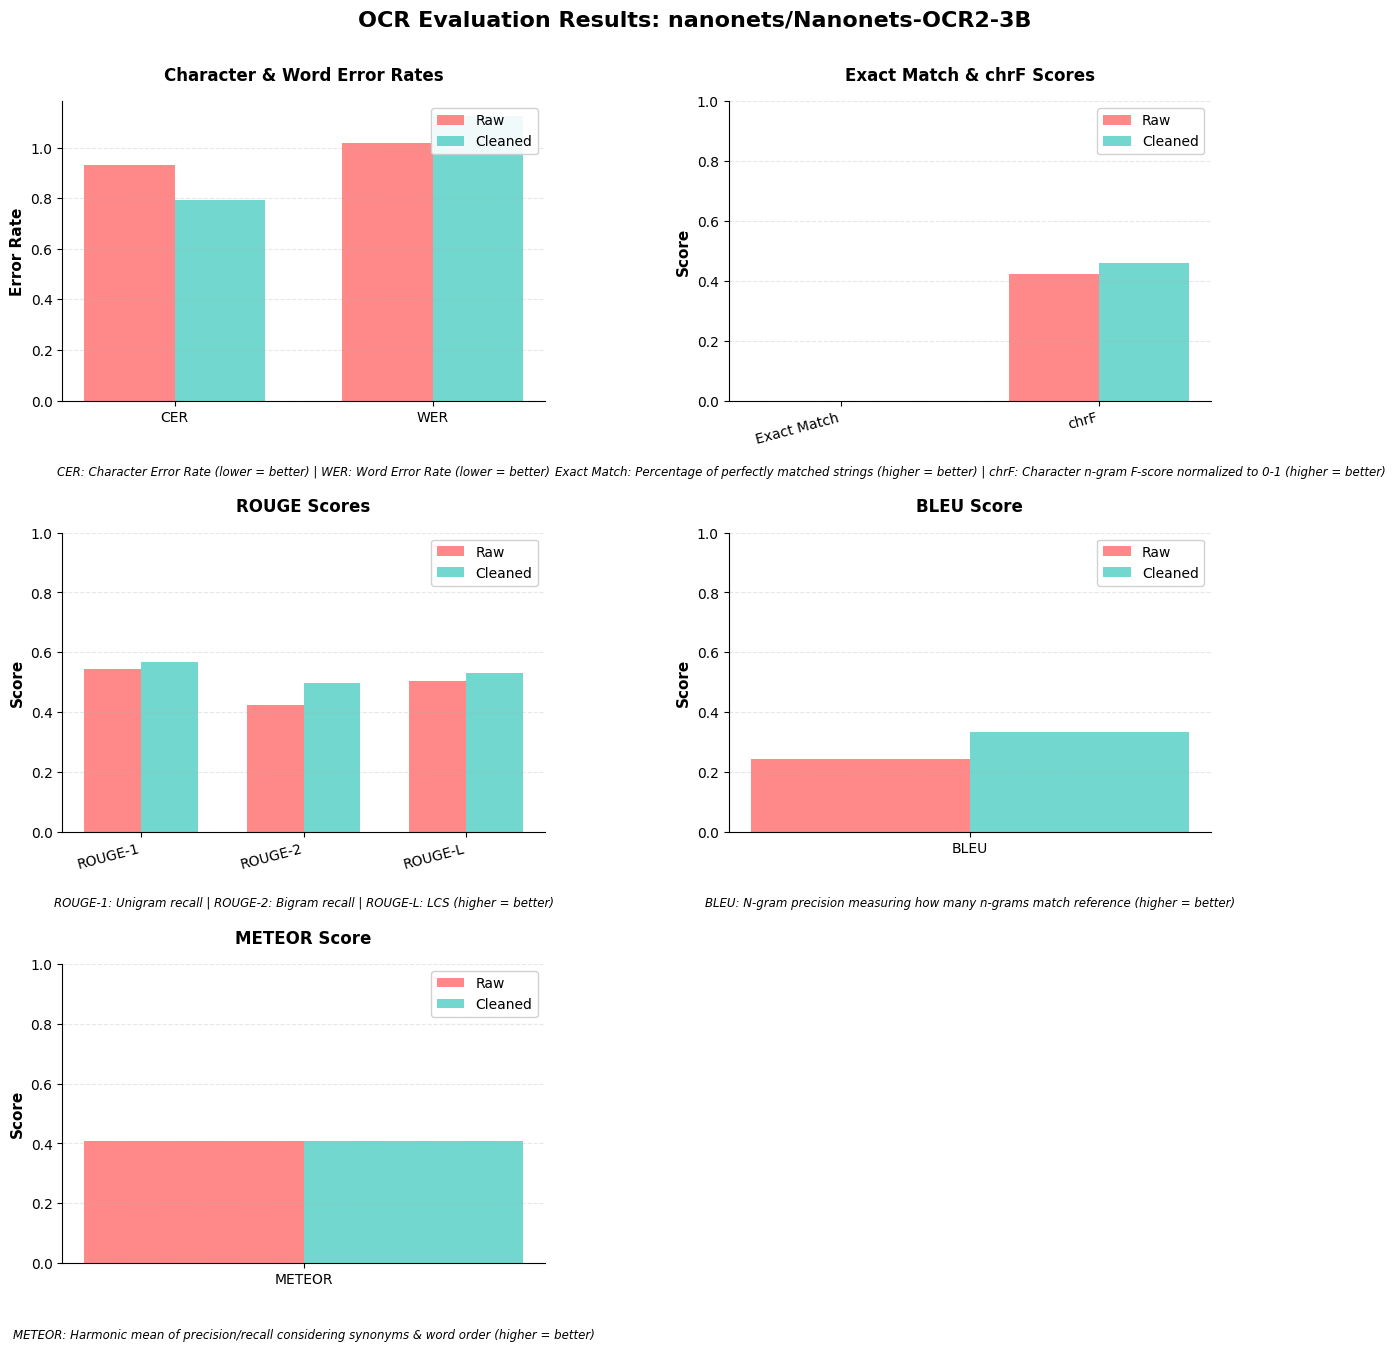

In [13]:
import matplotlib.pyplot as plt
import numpy as np

model_name = results["model_config"]["name"]
raw_metrics = results["metrics"]["raw"]
cleaned_metrics = results["metrics"]["cleaned"]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle(f'OCR Evaluation Results: {model_name}', fontsize=16, fontweight='bold', y=0.995)

width = 0.35
colors = {'raw': '#ff6b6b', 'cleaned': '#4ecdc4'}

ax1 = axes[0, 0]
cer_wer_labels = ['CER', 'WER']
raw_values = [raw_metrics['cer'], raw_metrics['wer']]
cleaned_values = [cleaned_metrics['cer'], cleaned_metrics['wer']]
x = np.arange(len(cer_wer_labels))
ax1.bar(x - width/2, raw_values, width, label='Raw', color=colors['raw'], alpha=0.8)
ax1.bar(x + width/2, cleaned_values, width, label='Cleaned', color=colors['cleaned'], alpha=0.8)
ax1.set_ylabel('Error Rate', fontsize=11, fontweight='bold')
ax1.set_title('Character & Word Error Rates', fontsize=12, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(cer_wer_labels)
ax1.legend(framealpha=0.9, loc='upper right')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.text(0.5, -0.25, 'CER: Character Error Rate (lower = better) | WER: Word Error Rate (lower = better)', 
         transform=ax1.transAxes, ha='center', fontsize=8.5, style='italic')

ax2 = axes[0, 1]
exact_chrf_labels = ['Exact Match', 'chrF']
raw_exact_chrf = [raw_metrics['exact_match']['exact_match'], raw_metrics['chrf']['score'] / 100.0]
cleaned_exact_chrf = [cleaned_metrics['exact_match']['exact_match'], cleaned_metrics['chrf']['score'] / 100.0]
x2 = np.arange(len(exact_chrf_labels))
ax2.bar(x2 - width/2, raw_exact_chrf, width, label='Raw', color=colors['raw'], alpha=0.8)
ax2.bar(x2 + width/2, cleaned_exact_chrf, width, label='Cleaned', color=colors['cleaned'], alpha=0.8)
ax2.set_ylabel('Score', fontsize=11, fontweight='bold')
ax2.set_title('Exact Match & chrF Scores', fontsize=12, fontweight='bold', pad=15)
ax2.set_xticks(x2)
ax2.set_xticklabels(exact_chrf_labels, rotation=15, ha='right')
ax2.legend(framealpha=0.9, loc='upper right')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim([0, 1])
ax2.text(0.5, -0.25, 'Exact Match: Percentage of perfectly matched strings (higher = better) | chrF: Character n-gram F-score normalized to 0-1 (higher = better)', 
         transform=ax2.transAxes, ha='center', fontsize=8.5, style='italic')

ax3 = axes[1, 0]
rouge_labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
raw_rouge = [raw_metrics['rouge'][m] for m in ['rouge1', 'rouge2', 'rougeL']]
cleaned_rouge = [cleaned_metrics['rouge'][m] for m in ['rouge1', 'rouge2', 'rougeL']]
x3 = np.arange(len(rouge_labels))
ax3.bar(x3 - width/2, raw_rouge, width, label='Raw', color=colors['raw'], alpha=0.8)
ax3.bar(x3 + width/2, cleaned_rouge, width, label='Cleaned', color=colors['cleaned'], alpha=0.8)
ax3.set_ylabel('Score', fontsize=11, fontweight='bold')
ax3.set_title('ROUGE Scores', fontsize=12, fontweight='bold', pad=15)
ax3.set_xticks(x3)
ax3.set_xticklabels(rouge_labels, rotation=15, ha='right')
ax3.legend(framealpha=0.9, loc='upper right')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.set_ylim([0, 1])
ax3.text(0.5, -0.25, 'ROUGE-1: Unigram recall | ROUGE-2: Bigram recall | ROUGE-L: LCS (higher = better)', 
         transform=ax3.transAxes, ha='center', fontsize=8.5, style='italic')

ax4 = axes[1, 1]
bleu_labels = ['BLEU']
raw_bleu = [raw_metrics['bleu']['bleu']]
cleaned_bleu = [cleaned_metrics['bleu']['bleu']]
x4 = np.arange(len(bleu_labels))
ax4.bar(x4 - width/2, raw_bleu, width, label='Raw', color=colors['raw'], alpha=0.8)
ax4.bar(x4 + width/2, cleaned_bleu, width, label='Cleaned', color=colors['cleaned'], alpha=0.8)
ax4.set_ylabel('Score', fontsize=11, fontweight='bold')
ax4.set_title('BLEU Score', fontsize=12, fontweight='bold', pad=15)
ax4.set_xticks(x4)
ax4.set_xticklabels(bleu_labels)
ax4.legend(framealpha=0.9, loc='upper right')
ax4.grid(axis='y', alpha=0.3, linestyle='--')
ax4.set_ylim([0, 1])
ax4.text(0.5, -0.25, 'BLEU: N-gram precision measuring how many n-grams match reference (higher = better)', 
         transform=ax4.transAxes, ha='center', fontsize=8.5, style='italic')

ax5 = axes[2, 0]
meteor_labels = ['METEOR']
raw_meteor = [raw_metrics['meteor']['meteor']]
cleaned_meteor = [cleaned_metrics['meteor']['meteor']]
x5 = np.arange(len(meteor_labels))
ax5.bar(x5 - width/2, raw_meteor, width, label='Raw', color=colors['raw'], alpha=0.8)
ax5.bar(x5 + width/2, cleaned_meteor, width, label='Cleaned', color=colors['cleaned'], alpha=0.8)
ax5.set_ylabel('Score', fontsize=11, fontweight='bold')
ax5.set_title('METEOR Score', fontsize=12, fontweight='bold', pad=15)
ax5.set_xticks(x5)
ax5.set_xticklabels(meteor_labels)
ax5.legend(framealpha=0.9, loc='upper right')
ax5.grid(axis='y', alpha=0.3, linestyle='--')
ax5.set_ylim([0, 1])
ax5.text(0.5, -0.25, 'METEOR: Harmonic mean of precision/recall considering synonyms & word order (higher = better)', 
         transform=ax5.transAxes, ha='center', fontsize=8.5, style='italic')

axes[2, 1].axis('off')

for ax in axes.flat:
    if ax != axes[2, 1]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()
